# Introduction

In the e-commerce and marketplace industry, acquiring a new customer is only the first step. Long-term profitability and sustainable growth are heavily dependent on **customer retention**.

The purpose of this notebook is to perform a **Time-Based Cohort Analysis** to evaluate user loyalty and track retention patterns over time. By grouping customers into cohorts based on the month of their first purchase, we can observe how their purchasing behavior changes in subsequent months.

# Data Load

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from src.helpers import load_view

df_cohort = load_view("vw_customer_monthly_activity")

In [3]:
df_cohort['cohort_month'] = pd.to_datetime(df_cohort['cohort_month']).dt.to_period('M')
df_cohort['purchase_month'] = pd.to_datetime(df_cohort['purchase_month']).dt.to_period('M')

Note: Cohorts from the end of 2016 are non-representative due to insufficient sample size during this timeframe. The primary analysis should focus on cohorts starting from 2017-01.

# Customer Cohort Analysis

In [4]:
c_cohort_matrix = df_cohort.pivot_table(
    index='cohort_month',
    columns='cohort_index',
    values='customer_unique_id',
    aggfunc='nunique'
)

print(c_cohort_matrix.head())

cohort_index    0.0   1.0   2.0   3.0   4.0   5.0   6.0   7.0   8.0   9.0   \
cohort_month                                                                 
2016-09          2.0   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
2016-10        290.0   NaN   NaN   NaN   NaN   NaN   1.0   NaN   NaN   1.0   
2016-12          1.0   1.0   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
2017-01        752.0   3.0   2.0   1.0   3.0   1.0   3.0   1.0   1.0   NaN   
2017-02       1690.0   4.0   5.0   2.0   7.0   2.0   4.0   3.0   2.0   3.0   

cohort_index  10.0  11.0  12.0  13.0  14.0  15.0  16.0  17.0  19.0  20.0  
cohort_month                                                              
2016-09        NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  
2016-10        NaN   1.0   NaN   1.0   NaN   1.0   NaN   1.0   2.0   2.0  
2016-12        NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  
2017-01        3.0   1.0   5.0   3.0   1.0   1.0   2.0   3.0   1.0   NaN  
201

In [5]:
cohort_sizes = c_cohort_matrix.iloc[:, 0]
retention_matrix = c_cohort_matrix.divide(cohort_sizes, axis=0).round(3)

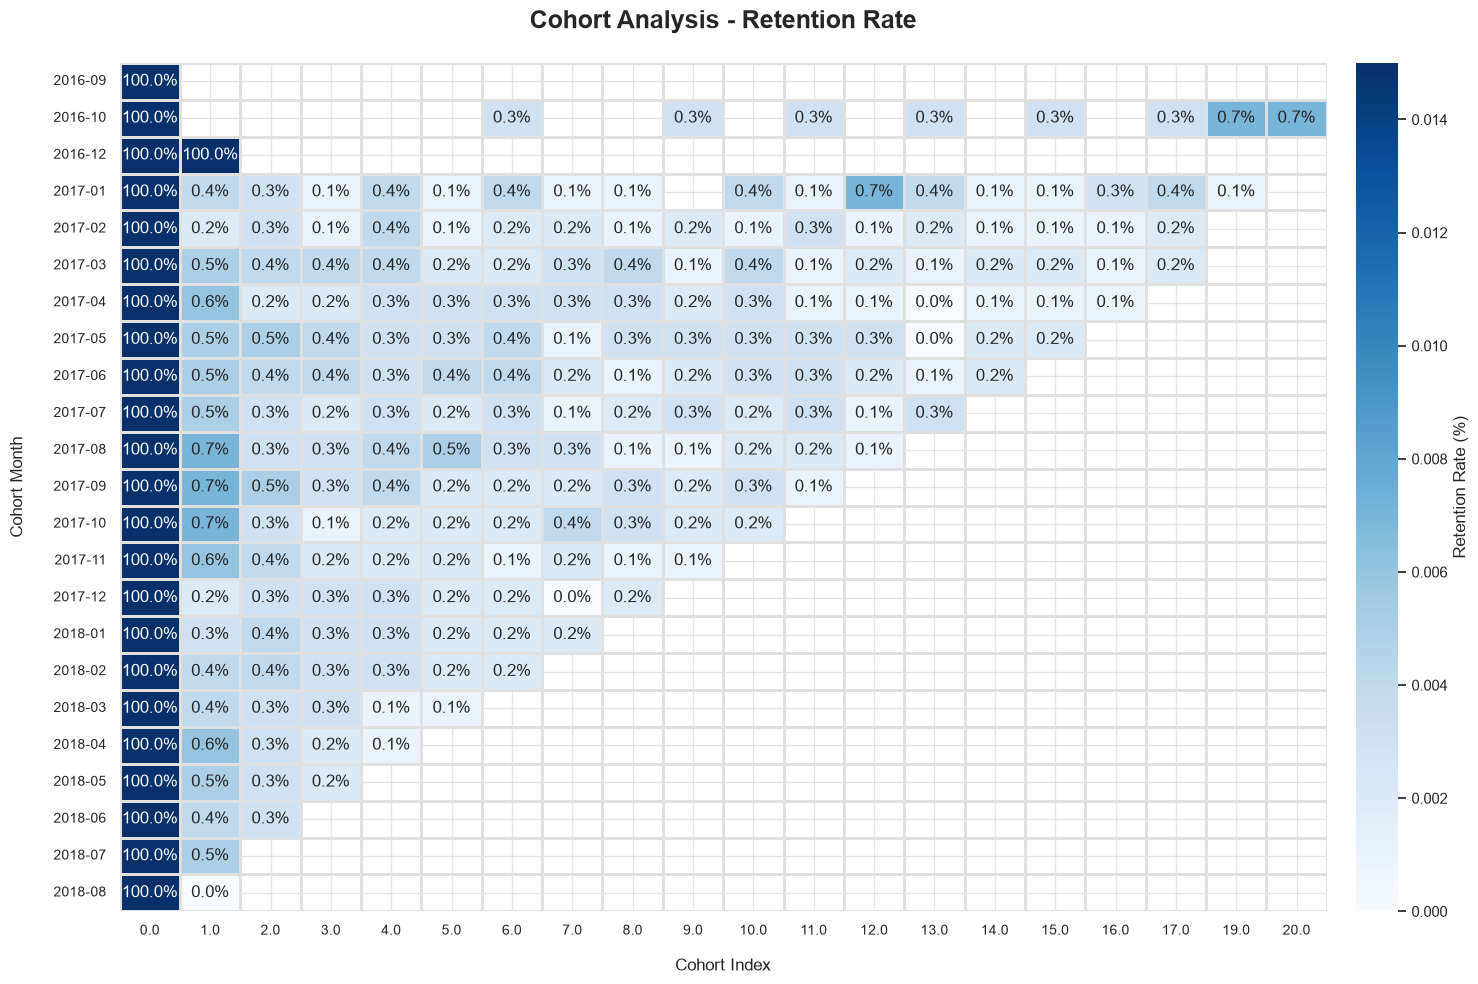

In [6]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(16, 10))

sns.heatmap(
    data=retention_matrix,
    annot=True,
    fmt='.1%',
    cmap='Blues',
    vmax=0.015,
    linewidths=0.8,
    linecolor='#e0e0e0',
    cbar_kws={'label': 'Retention Rate (%)', 'pad': 0.02},
    ax=ax
)

ax.set_title('Cohort Analysis - Retention Rate', fontsize=18, fontweight='bold', pad=25)
ax.set_xlabel('Cohort Index', fontsize=12, labelpad=15)
ax.set_ylabel('Cohort Month', fontsize=12, labelpad=20)

plt.xticks(rotation=0, fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()

plt.show()

# Revenue Cohort Analysis

In [7]:
r_cohort_matrix = df_cohort.pivot_table(
    index='cohort_month',
    columns='cohort_index',
    values='revenue_in_month',
    aggfunc='sum'
)

print(r_cohort_matrix.head())

cohort_index       0.0     1.0     2.0     3.0      4.0    5.0     6.0   \
cohort_month                                                              
2016-09          136.23     NaN     NaN     NaN      NaN    NaN     NaN   
2016-10        51657.53     NaN     NaN     NaN      NaN    NaN  111.30   
2016-12           19.62   19.62     NaN     NaN      NaN    NaN     NaN   
2017-01       136987.14  170.83  114.70   89.70   246.25  69.33  448.43   
2017-02       283451.11  536.12  570.63  118.73  1151.96  74.21  688.92   

cohort_index    7.0     8.0     9.0     10.0    11.0    12.0    13.0    14.0  \
cohort_month                                                                   
2016-09          NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
2016-10          NaN     NaN  356.13     NaN   56.78     NaN  163.53     NaN   
2016-12          NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
2017-01       105.17   47.05     NaN  427.05   66.60  552.45  351.65   93.

In [8]:
cohort_revenue_sizes = r_cohort_matrix.iloc[:, 0]
revenue_retention_matrix = r_cohort_matrix.divide(cohort_revenue_sizes, axis=0).round(3)

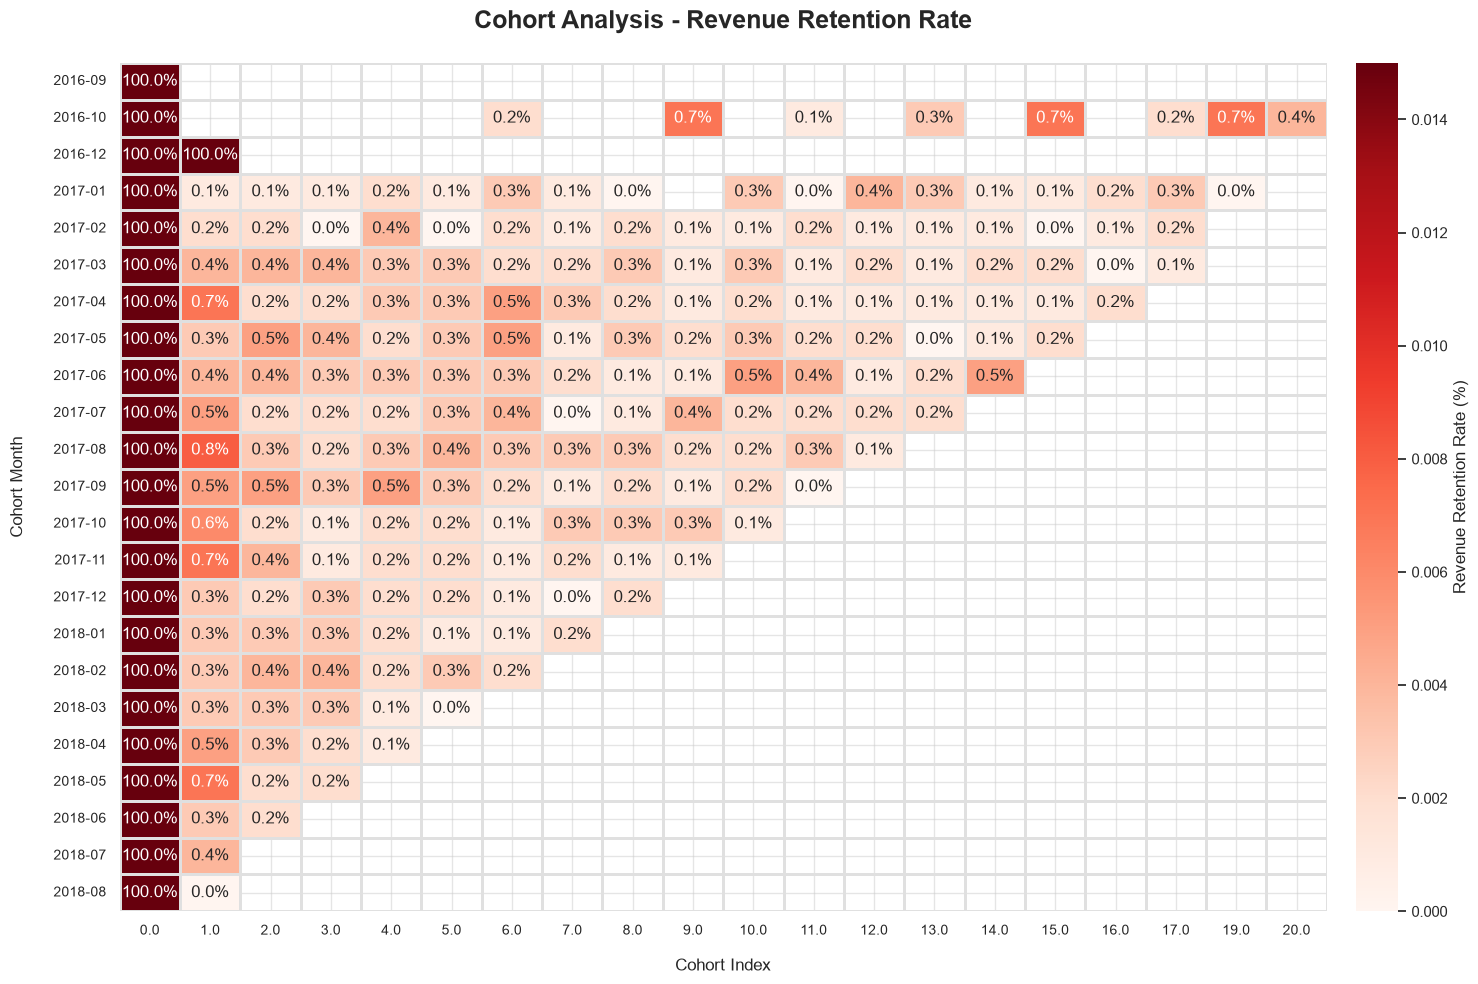

In [9]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(16, 10))

sns.heatmap(
    data=revenue_retention_matrix,
    annot=True,
    fmt='.1%',
    cmap='Reds',
    vmax=0.015,
    linewidths=0.8,
    linecolor='#e0e0e0',
    cbar_kws={'label': 'Revenue Retention Rate (%)', 'pad': 0.02},
    ax=ax
)

ax.set_title('Cohort Analysis - Revenue Retention Rate', fontsize=18, fontweight='bold', pad=25)
ax.set_xlabel('Cohort Index', fontsize=12, labelpad=15)
ax.set_ylabel('Cohort Month', fontsize=12, labelpad=20)

plt.xticks(rotation=0, fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()

plt.show()

# Key Takeaways

<b>Business Model</b>: This pattern confirms that Olist operates primarily on a one-time transaction model. The business growth depends on continuously acquiring new customers rather than retaining existing ones.

<b>Loyalty</b>: Overall customer retention is extremely low. The vast majority of users make a single purchase and never return to the platform.

<b>Baseline</b>: The very small percentage of customers who do return tend to remain active at a stable, low rate (0.1% to 0.4%) for 12 or more months. It seems that Power User group exists on that platform as Revenue Retention is higher than User Retention would indicate.

<b>Recommendations</b>: The business should introduce welcome offers, retargeting ads, or loyalty programs immediately after the first purchase to encourage a second order. Analyze and possibly replicate campaigns that took place around August - October 2017 as cohorts from those months performed slightly better in Month 1 (0.7%).